In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
import numpy as np
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")



In [3]:
df=pd.read_csv("E:/data science/ml_regression/Cellphone.csv")
df.head()

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,203,2357,10,135.0,5.2,424,8,1.35,16.0,3.000,13.00,8.0,2610,7.4
1,880,1749,10,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9
2,40,1916,10,110.0,4.7,312,4,1.20,8.0,1.500,13.00,5.0,2000,7.6
3,99,1315,11,118.5,4.0,233,2,1.30,4.0,0.512,3.15,0.0,1400,11.0
4,880,1749,11,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9


In [9]:
df.rename(columns={'resoloution':'resolution','internal mem':'internal_mem','cpu freq':'cpu_freq', 'cpu core':'cpu_core'}, inplace=True)
df.head(4)

,Price,Sale,weight,resolution,ppi,cpu_core,cpu_freq,internal_mem,ram,RearCam,Front_Cam,battery,thickness
0,2357,10,135.0,5.2,424,8,1.35,16.0,3.000,13.00,8.0,2610,7.4
1,1749,10,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9
2,1916,10,110.0,4.7,312,4,1.20,8.0,1.500,13.00,5.0,2000,7.6
3,1315,11,118.5,4.0,233,2,1.30,4.0,0.512,3.15,0.0,1400,11.0


In [12]:
print(df.shape)

print(df.info)
print(df.isnull().sum().sum())
print(df.duplicated().sum())


(161, 13)
<bound method DataFrame.info of      Price  Sale  weight  resolution  ppi  cpu_core  cpu_freq  internal_mem  \
0     2357    10   135.0        5.20  424         8     1.350          16.0   
1     1749    10   125.0        4.00  233         2     1.300           4.0   
2     1916    10   110.0        4.70  312         4     1.200           8.0   
3     1315    11   118.5        4.00  233         2     1.300           4.0   
4     1749    11   125.0        4.00  233         2     1.300           4.0   
..     ...   ...     ...         ...  ...       ...       ...           ...   
156   3551  4638   178.0        5.46  538         4     1.875         128.0   
157   3211  8016   170.0        5.50  534         4     1.975         128.0   
158   3260  8809   150.0        5.50  401         8     2.200          64.0   
159   3211  8946   170.0        5.50  534         4     1.975         128.0   
160   2536  9807   202.0        6.00  367         8     1.500          16.0   

       ra

In [13]:
df.drop(columns=['Product_id'],inplace=True)

KeyError: "['Product_id'] not found in axis"

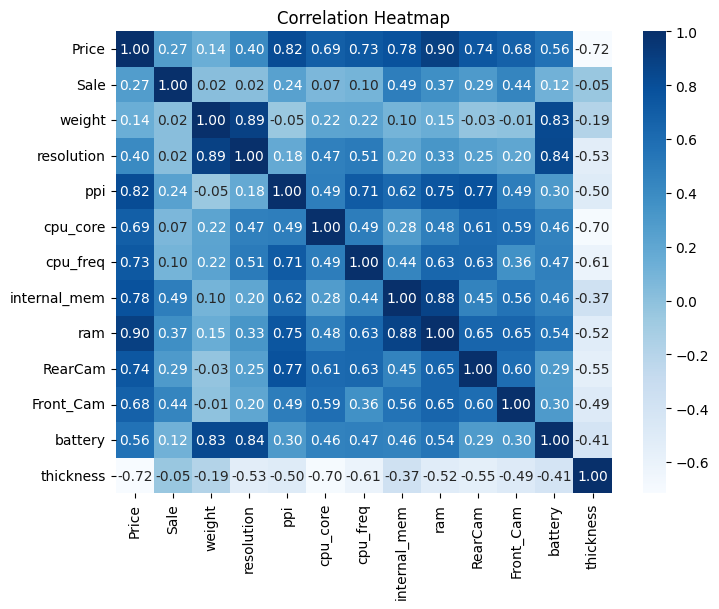

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,161.0,2215.596273,768.187171,614.0,1734.0,2258.00,2744.000,4361.0
Sale,161.0,621.465839,1546.618517,10.0,37.0,106.00,382.000,9807.0
weight,161.0,170.426087,92.888612,66.0,134.1,153.00,170.000,753.0
resolution,161.0,5.209938,1.509953,1.4,4.8,5.15,5.500,12.2
ppi,161.0,335.055901,134.826659,121.0,233.0,294.00,428.000,806.0
cpu_core,161.0,4.857143,2.444016,0.0,4.0,4.00,8.000,8.0
cpu_freq,161.0,1.502832,0.599783,0.0,1.2,1.40,1.875,2.7
internal_mem,161.0,24.501714,28.804773,0.0,8.0,16.00,32.000,128.0
ram,161.0,2.204994,1.609831,0.0,1.0,2.00,3.000,6.0
RearCam,161.0,10.378261,6.181585,0.0,5.0,12.00,16.000,23.0


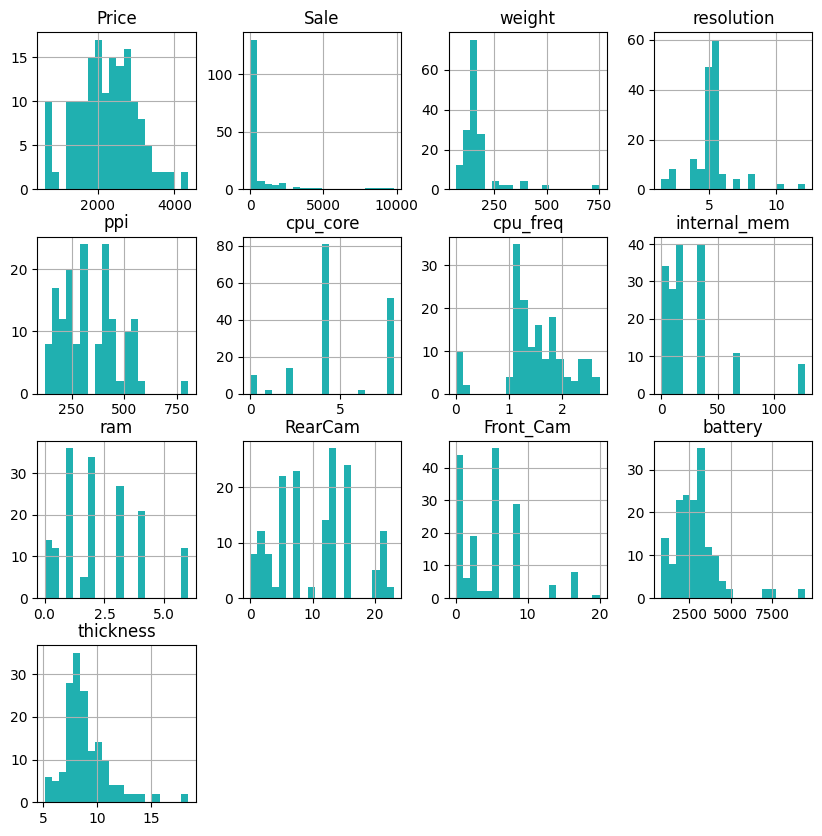

In [16]:
df.hist(figsize=(10,10),bins=20,color='#20B0B0')
plt.show()

In [17]:
skewness= df.skew()
print(skewness)

Price           0.052347
Sale            4.269384
weight          3.981756
resolution      1.176110
ppi             0.602503
cpu_core       -0.009077
cpu_freq       -0.512663
internal_mem    2.389683
ram             0.792698
RearCam         0.106929
Front_Cam       1.169750
battery         2.092660
thickness       1.587680
dtype: float64


In [18]:
skewed_columns=['Sale','weight','resolution','internal_mem','Front_Cam','battery','thickness']

for i in skewed_columns:
   df[i]=np.log1p(df[i])
df[skewed_columns].skew()

Sale            0.614823
weight          1.322798
resolution     -1.068191
internal_mem   -0.621898
Front_Cam      -0.316747
battery        -0.361261
thickness       0.591625
dtype: float64

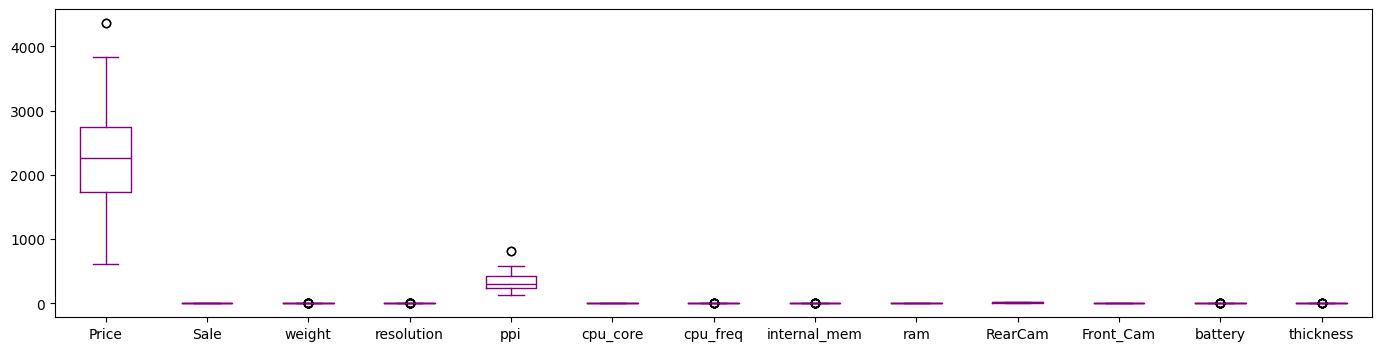

In [19]:
df.plot (kind='box',figsize=(17,4),color='purple')
plt.show()

In [20]:
Q1=df.quantile(0.25)
Q3=df.quantile(0.75)
IQR=Q3-Q1
ur=Q3+ 1.5*IQR
lr=Q1- 1.5*IQR
       

In [21]:
cols=["cpu_core", "cpu_freq", "internal_mem", "ram"]
df[cols]=df[cols].replace(0,np.nan)
for i in cols:
    df[i]=df[i].fillna(df[i].median())
print(df[cols].isnull().sum())  

cpu_core        0
cpu_freq        0
internal_mem    0
ram             0
dtype: int64


In [22]:
# regressix=df.drop('Price',axis=1)
x=df.drop('Price',axis=1)
y=df['Price']
x_train,x_test,y_train,y_test=train_test_split(x,y ,train_size=0.7,random_state=1)
x_train.shape,x_test.shape,y_train.shape,y_test.shape


((112, 12), (49, 12), (112,), (49,))

In [23]:
scaler=StandardScaler()
x_train_sc=scaler.fit_transform(x_train)
x_test_sc = scaler.transform(x_test)



x_train=pd.DataFrame(x_train_sc,columns=x_train.columns,index=x_train.index)
x_test=pd.DataFrame(x_test_sc,columns=x_test.columns,index=x_test.index)

x_train.head(2)

,Sale,weight,resolution,ppi,cpu_core,cpu_freq,internal_mem,ram,RearCam,Front_Cam,battery,thickness
105,0.256799,-1.810961,-2.146806,-1.278399,-0.5581,-0.238272,-0.024016,-1.416511,-1.672314,-1.480554,-1.755691,1.734419
28,-1.009838,-0.137178,0.037757,-0.889497,-0.5581,-0.923534,-0.669667,-0.804013,-0.876718,0.475640,-0.607918,0.036714


In [24]:
lm=LinearRegression()
lm.fit(x_train,y_train)

train_pred_lm = lm.predict(x_train)
test_pred_lm = lm.predict(x_test)

print('LinearRegression')
print("train r2:",r2_score(y_train,train_pred_lm))
print("test r2:",r2_score(y_test,test_pred_lm))


LinearRegression
train r2: 0.9343521988995742
test r2: 0.9362401759905608


In [25]:
ridge=Ridge(alpha=0.1)
ridge.fit(x_train,y_train)
train_pred_ridge=ridge.predict(x_train)
test_pred_ridge=ridge.predict(x_test)
print("ridge regression")
print('train r2:',r2_score(y_train,train_pred_ridge))
print("test r2:",r2_score(y_test,test_pred_ridge))
                          


ridge regression
train r2: 0.9343489904221689
test r2: 0.9365992646374806


In [26]:
lasso=Lasso(alpha=0.1)
lasso.fit(x_train,y_train)
train_pred_lasso=lasso.predict(x_train)
test_pred_lasso=lasso.predict(x_test)
print("lasso regression")
print('train r2:',r2_score(y_train,train_pred_lasso))
print("test r2:",r2_score(y_test,test_pred_lasso))
                          

lasso regression
train r2: 0.9343507585227613
test r2: 0.9364749445353925


In [27]:
elasticnet=ElasticNet(alpha=0.1, l1_ratio=0.5)
elasticnet.fit(x_train,y_train)
train_pred_elasticnet=elasticnet.predict(x_train)             
test_pred_elasticnet=elasticnet.predict(x_test)
print("ElasticNet")
print('train r2:',r2_score(y_train,train_pred_elasticnet))
print("test r2:",r2_score(y_test,test_pred_elasticnet))


ElasticNet
train r2: 0.9307356069711192
test r2: 0.9444796122256365


In [28]:
result=pd.DataFrame({

    'model':['Linear','Ridge','Lasso','ElasticNet'],
    'train R2':[
        r2_score(y_train,train_pred_lm),
        r2_score(y_train,train_pred_ridge),
        r2_score(y_train,train_pred_lasso),
        r2_score(y_train,train_pred_elasticnet)
                
    
    ],
    'test R2':[
        r2_score(y_test,test_pred_lm),
        r2_score(y_test,test_pred_ridge),
        r2_score(y_test,test_pred_lasso),
        r2_score(y_test,test_pred_elasticnet)
    ],
                
     'train_MAE':[
              mean_absolute_error(y_train,train_pred_lm),
              mean_absolute_error(y_train,train_pred_ridge),
              mean_absolute_error(y_train,train_pred_lasso),
              mean_absolute_error(y_train,train_pred_elasticnet)

     ],
    'test_MAE':[
              mean_absolute_error(y_train,train_pred_lm),
              mean_absolute_error(y_train,train_pred_ridge),
              mean_absolute_error(y_train,train_pred_lasso),
              mean_absolute_error(y_train,train_pred_elasticnet)
    ],

     'train_RMSE':[
         np.sqrt(mean_squared_error(y_train,train_pred_lm)),
         np.sqrt(mean_squared_error(y_train,train_pred_ridge)),
         np.sqrt(mean_squared_error(y_train,train_pred_lasso)),
         np.sqrt(mean_squared_error(y_train,train_pred_elasticnet))

     ],


     
        'train_RMSE':[
         np.sqrt(mean_squared_error(y_train,train_pred_lm)),
         np.sqrt(mean_squared_error(y_train,train_pred_ridge)),
         np.sqrt(mean_squared_error(y_train,train_pred_lasso)),
         np.sqrt(mean_squared_error(y_train,train_pred_elasticnet))

        ],
    'test_RMSE':[
         np.sqrt(mean_squared_error(y_train,train_pred_lm)),
         np.sqrt(mean_squared_error(y_train,train_pred_ridge)),
         np.sqrt(mean_squared_error(y_train,train_pred_lasso)),
         np.sqrt(mean_squared_error(y_train,train_pred_elasticnet))
    ]

})
         
result
    
    

,model,train R2,test R2,train_MAE,test_MAE,train_RMSE,test_RMSE
0,Linear,0.934352,0.936240,165.784660,165.784660,202.456161,202.456161
1,Ridge,0.934349,0.936599,165.779494,165.779494,202.461108,202.461108
2,Lasso,0.934351,0.936475,165.790997,165.790997,202.458382,202.458382
3,ElasticNet,0.930736,0.944480,166.823786,166.823786,207.958139,207.958139


In [29]:
test_pred_elasticnet = elasticnet.predict(x_test)
test_predictions_df=pd.DataFrame({
    "actual_price" : y_test.values.flatten(),
    "predicted_price": test_pred_elasticnet
})
test_predictions_df.to_csv("test_predictions.csv",index=False)

print("test_predictions.csv created successfully")
print("Shape:", test_predictions_df.shape)
display(test_predictions_df.head())


test_predictions.csv created successfully
Shape: (49, 2)


,actual_price,predicted_price
0,2859,2985.902160
1,3316,2797.204846
2,754,883.323137
3,1396,1611.736815
4,3260,3049.896852


In [31]:

import joblib

joblib.dump(elasticnet, 'price_prediction.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']